# Unsupervised Clustering of Wound Border Features
This notebook performs dimensionality reduction and clustering on the extracted wound border features to identify patterns and group similar wounds.

## Loading Feature Vectors and Cleaning Dataset

In [1]:
## loading extracted feature vectors

import pandas as pd
import numpy as np
# load the full feature vectors csv
try:
    df = pd.read_csv("../outputs/comprehensive_features.csv")
    print(f"Loaded {len(df)} feature rows")
    
    #clean the dataset dropping rows with NaN values
    df_clean = df.dropna()
    image_ids = df_clean["image_id"].values
    features = df_clean.drop(columns=["image_id"]).values
    print(f"{len(features)} rows remainign after dropping NaNs")

except FileNotFoundError:
    print("ERROR: CSV file not found. Please ensure the path is correct or run 'run_pipelines.py' to generate the file.")

Loaded 1169 feature rows
1169 rows remainign after dropping NaNs


## Dimensionality Reduction for Visalization and Clustering with HDBSCAN

In [ ]:
# Diamensionality reduction with PaCMAP
import pacmap
from sklearn.preprocessing import StandardScaler

# ----Scale the Features ---
# Standardizes each feature to have a mean of 0 and a standard deviation of 1, 
# ensuring all features contribute equally.
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# ----Apply PaCMAP for Dimensionality Reduction---
# config for 2D results n_components=2
pmap = pacmap.PaCMAP(
    n_components=2,
    n_neighbors=None,     
    MN_ratio=5,
    FP_ratio=15,
    random_state=42,
    distance='euclidean'
)

embedding = pmap.fit_transform(features_scaled)

In [ ]:
# Clustering using HDBSCAN
import hdbscan
#import numpy as np

# Cluster in reduced 2D space
clusterer = hdbscan.HDBSCAN(
    min_cluster_size= 20,
    min_samples=15,
    cluster_selection_epsilon=0.75,
    cluster_selection_method='eom',
    core_dist_n_jobs=-1,
    metric='euclidean'
)
# Assigning cluster labels for data points spread in 2D map
cluster_labels = clusterer.fit_predict(embedding)

# Add to dataFrame
df_clean["cluster_label"] = cluster_labels

num_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
num_noise = np.sum(cluster_labels == -1)

print(f"Clustering complete. Found {num_clusters} clusters and {num_noise} noise points.")

#unique, counts = np.unique(labels, return_counts=True)
#print("Cluster counts:", dict(zip(unique, counts)))

Clustering complete. Found 6 clusters and 1 noise points.


/opt/anaconda3/envs/wound-pr/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/wound-pr/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


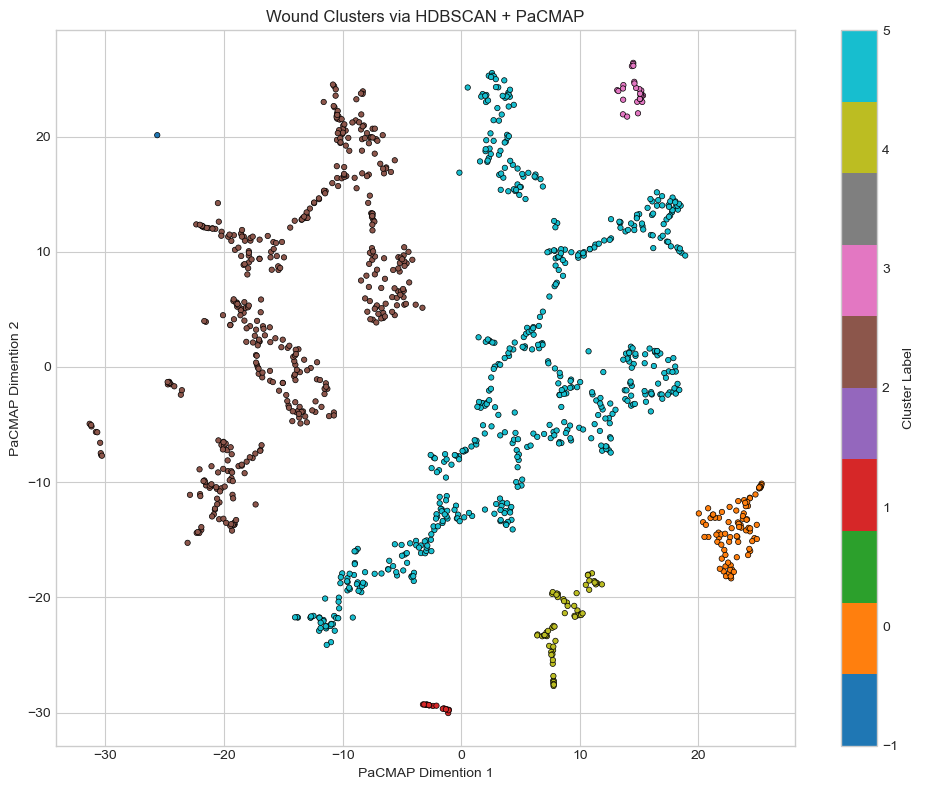

In [71]:
# visualize the clusters
import matplotlib.pyplot as plt

#plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 8))

plt.scatter(x=embedding[:, 0], y=embedding[:, 1], c=cluster_labels, cmap="tab10", s=15, edgecolors='black', linewidths=0.5)
plt.title("Wound Clusters via HDBSCAN + PaCMAP")
plt.xlabel("PaCMAP Dimention 1")
plt.ylabel("PaCMAP Dimention 2")
plt.colorbar(label="Cluster Label")
plt.grid(True)
plt.tight_layout()
plt.show()

## Saving Image Cluster Map

In [47]:
# Displaing Cluster Details: Number of samples in each cluster
import numpy as np
unique, counts = np.unique(cluster_labels, return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(-1): np.int64(1), np.int64(0): np.int64(87), np.int64(1): np.int64(20), np.int64(2): np.int64(430), np.int64(3): np.int64(28), np.int64(4): np.int64(62), np.int64(5): np.int64(541)}


In [48]:
# Extract image IDs and their cluster assignments
image_clusters = df_clean[["image_id", "cluster_label"]]

# Save to a separate CSV
image_clusters.to_csv("../outputs/image_cluster_map.csv", index=False)

print("Saved cluster assignments to image_cluster_map.csv")

Saved cluster assignments to image_cluster_map.csv


## Preview Sample Images by Cluster


Cluster -1 — Showing 1 of 1 sample(s)


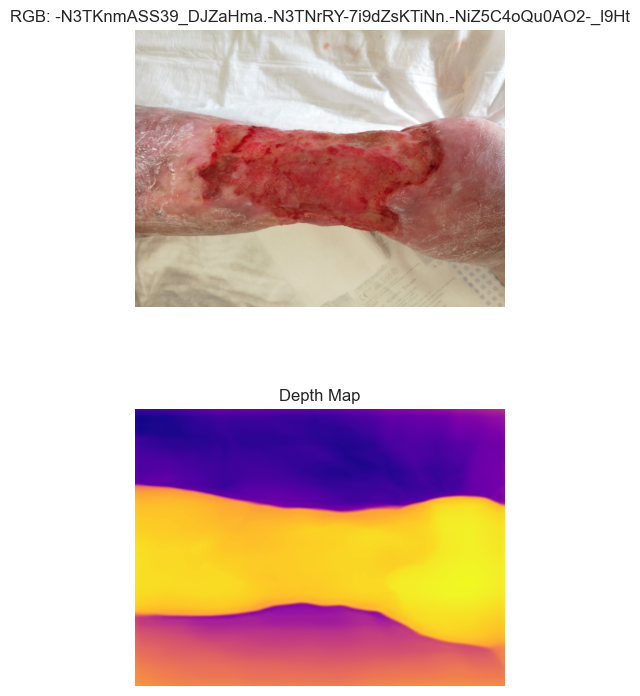


Cluster 0 — Showing 3 of 87 sample(s)


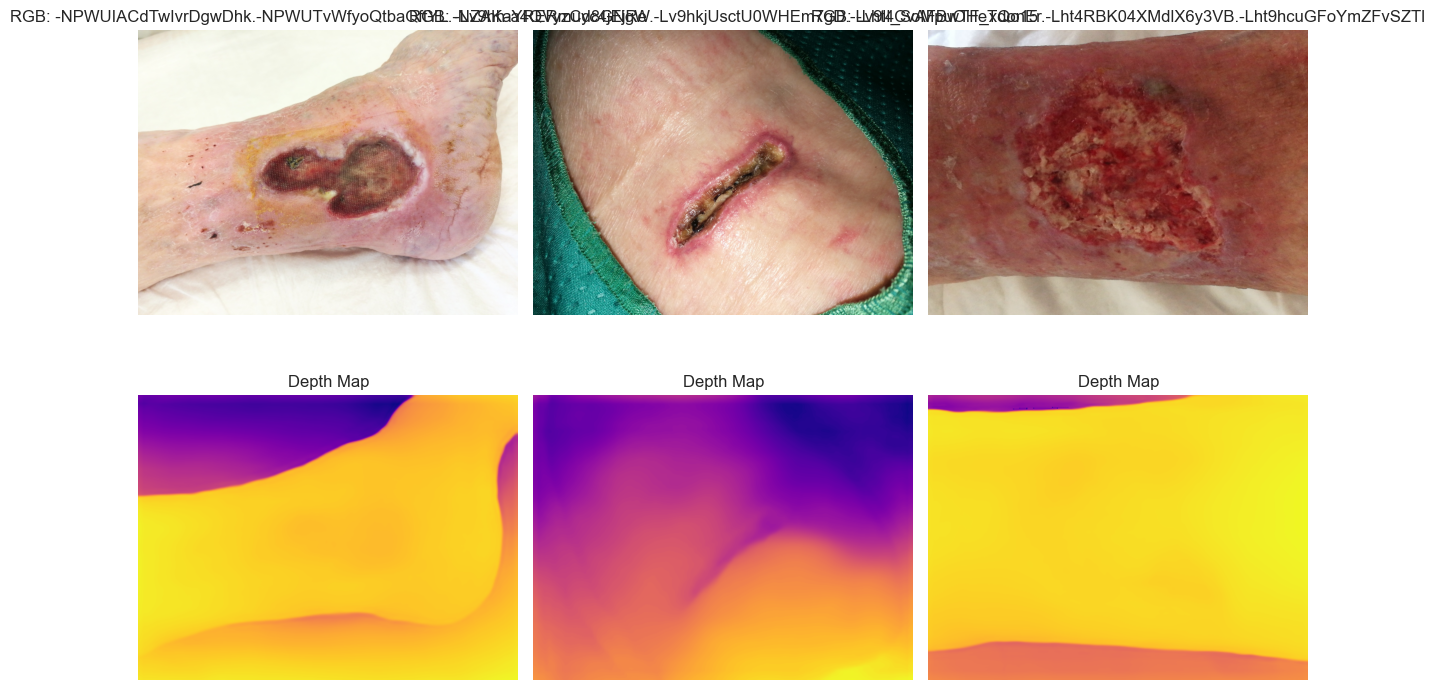


Cluster 1 — Showing 3 of 20 sample(s)


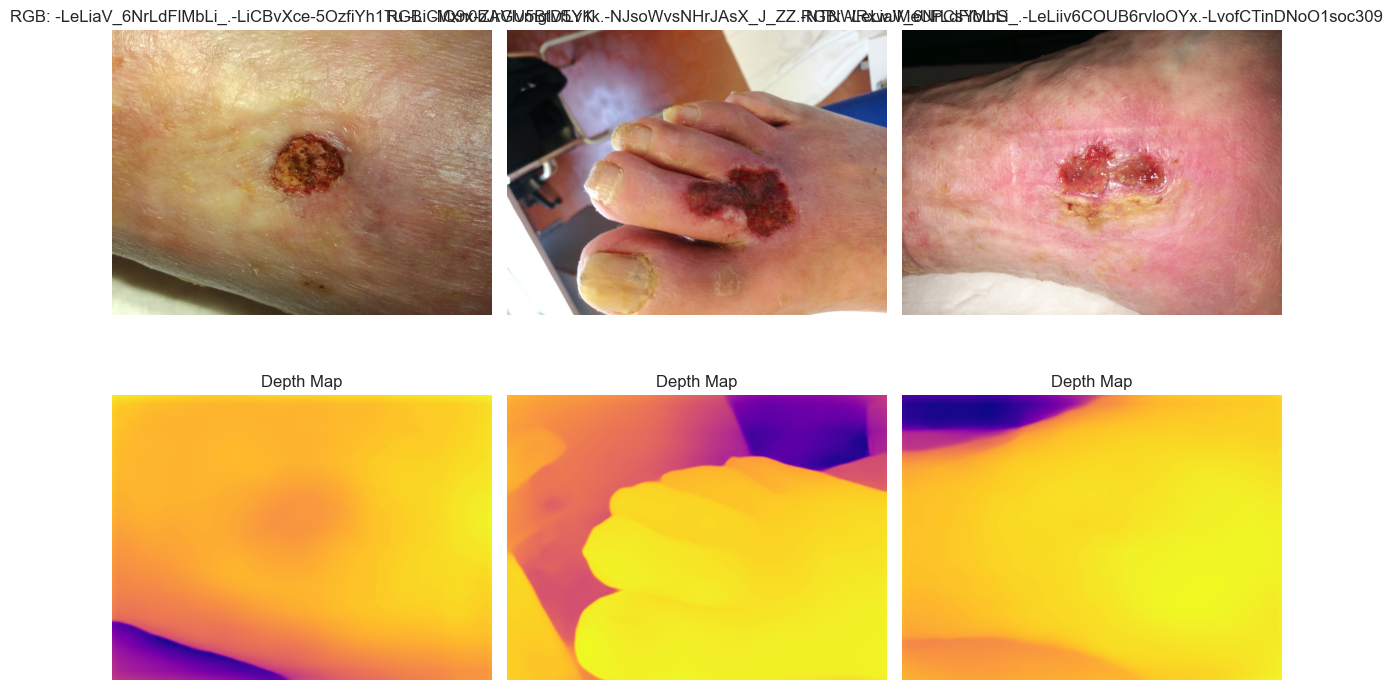


Cluster 2 — Showing 3 of 430 sample(s)


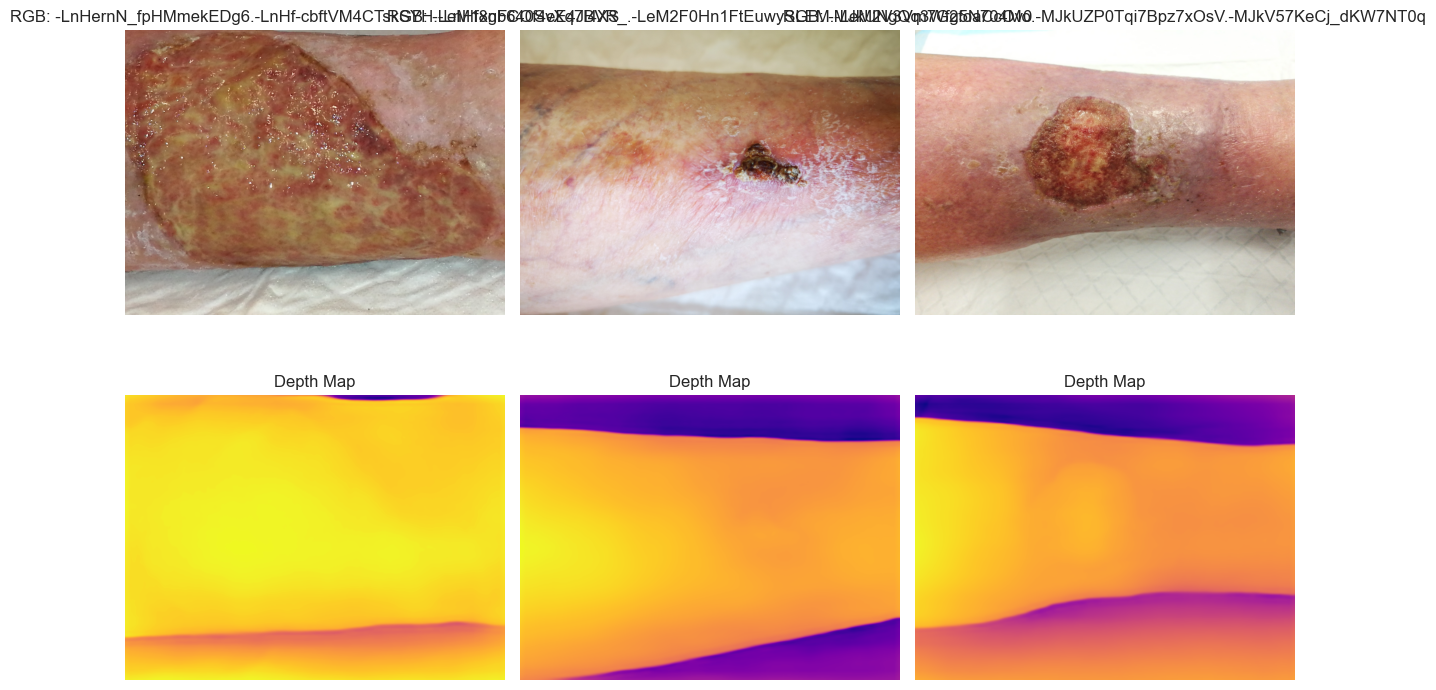


Cluster 3 — Showing 3 of 28 sample(s)


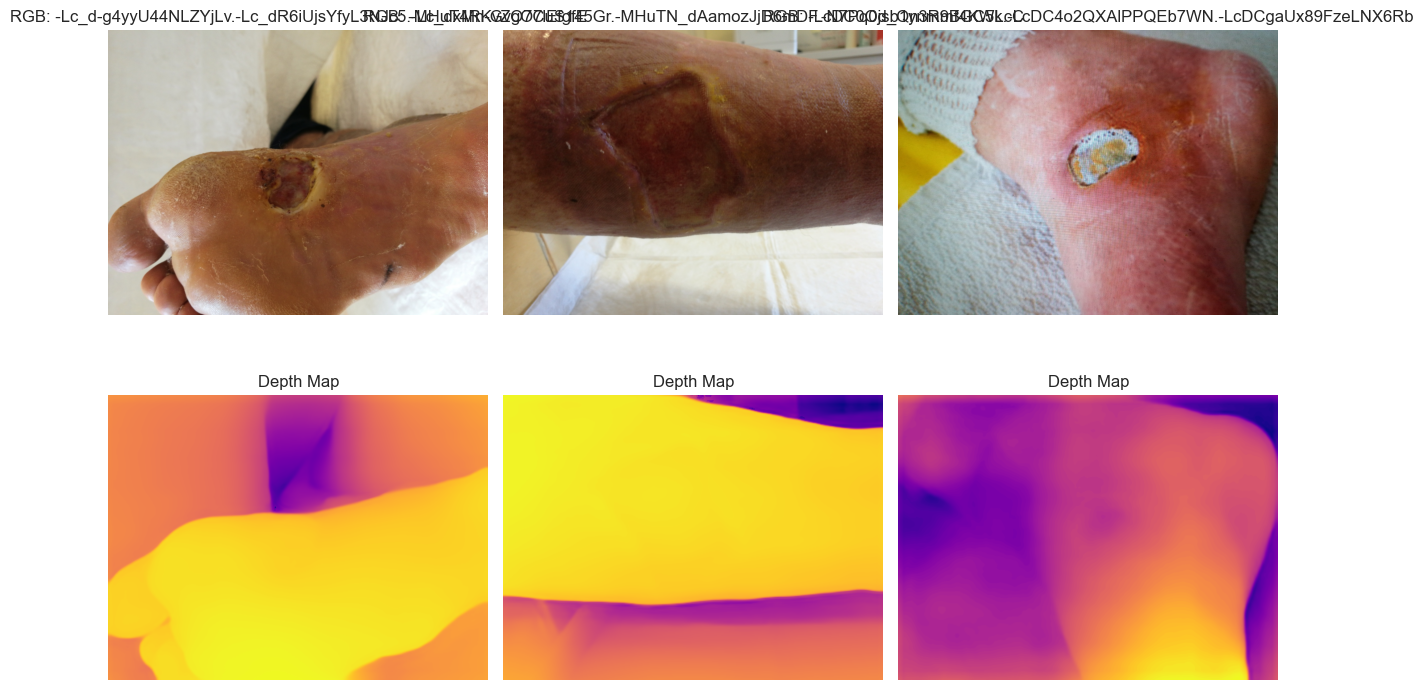


Cluster 4 — Showing 3 of 62 sample(s)


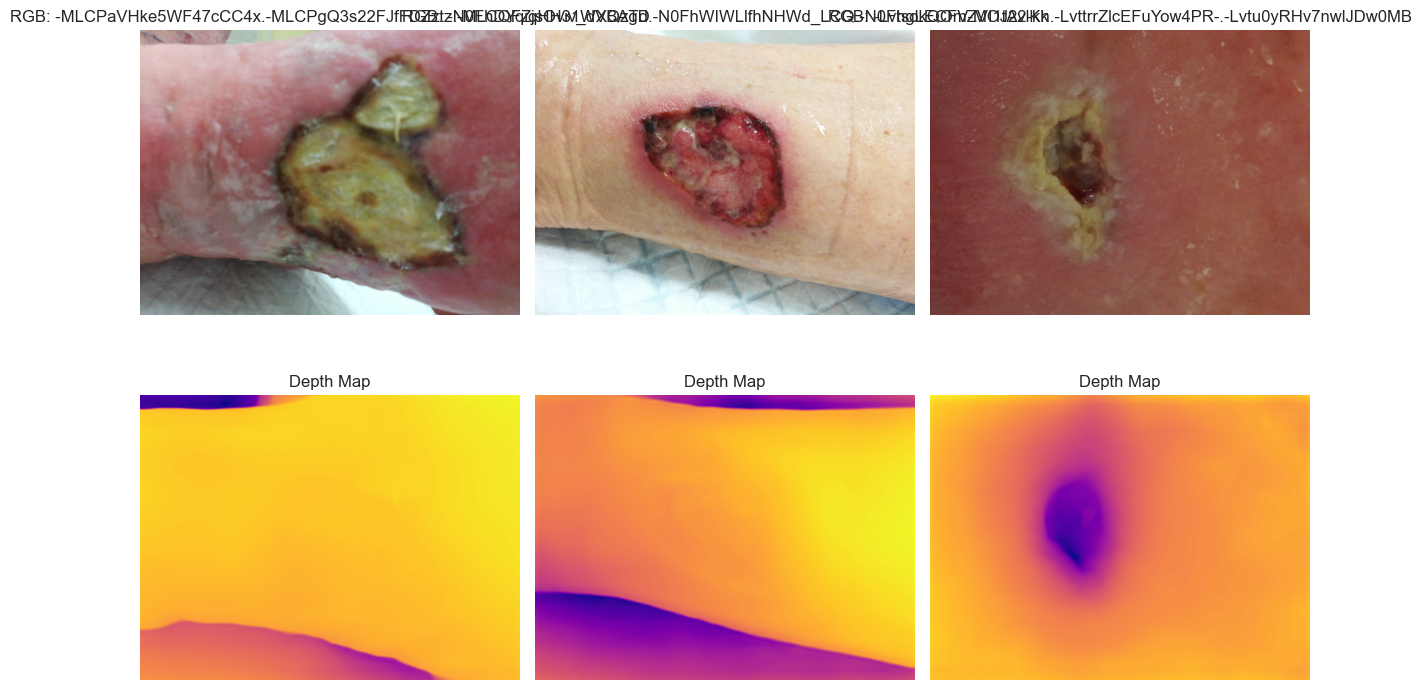


Cluster 5 — Showing 3 of 541 sample(s)


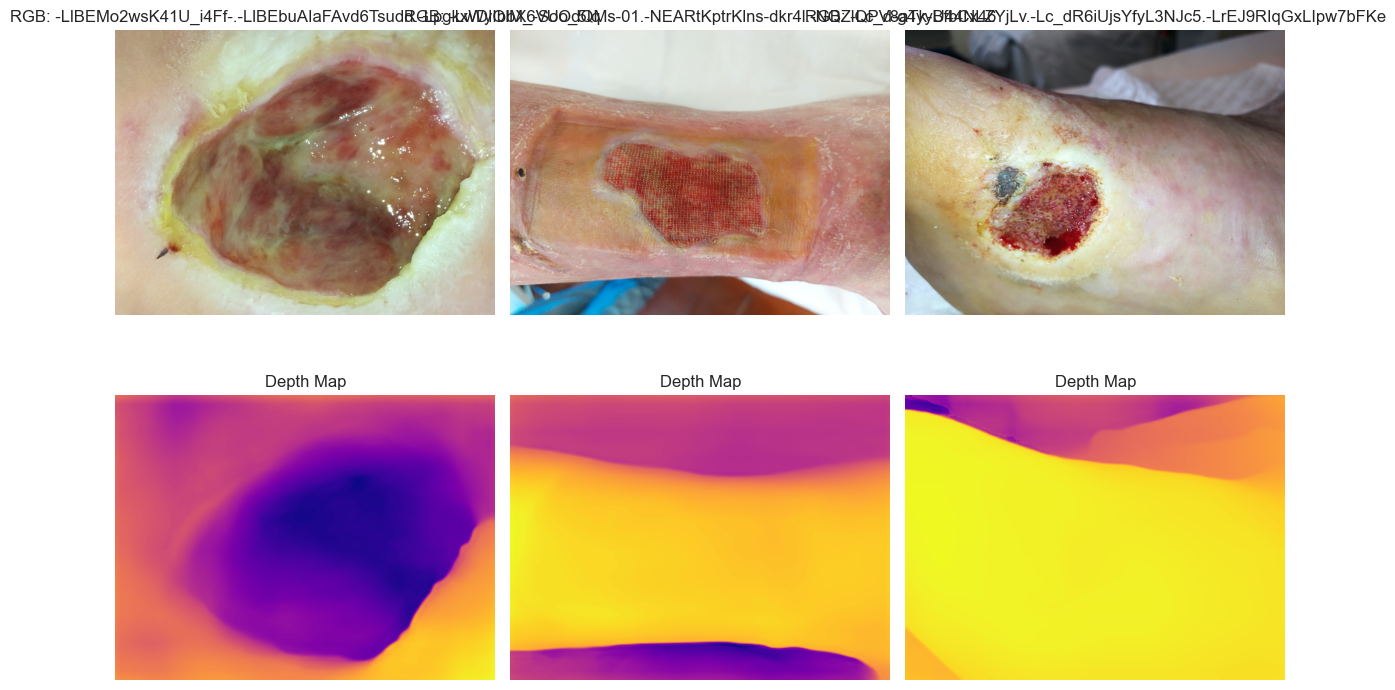

In [74]:
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Load cluster mapping CSV
cluster_map = pd.read_csv("../outputs/image_cluster_map.csv")

# Group image IDs by cluster
cluster_groups = cluster_map.groupby("cluster_label")["image_id"].apply(list)

def preview_cluster_samples(cluster_id, sample_count=3, data_root="../data"):
    """
    Displays a preview of sample images and their depth maps for a given cluster.
    RGB images are in the top row, and corresponding depth maps are in the bottom row.
    """
    image_ids = cluster_groups.get(cluster_id, [])
    
    # Determine the actual number of samples to show
    num_to_show = min(sample_count, len(image_ids))

    print(f"\nCluster {cluster_id} — Showing {num_to_show} of {len(image_ids)} sample(s)")
    
    if num_to_show == 0:
        # No need to print "No samples available" as the line above handles it.
        return
        
    # Get a random subset of images to display
    samples_to_show = np.random.choice(image_ids, num_to_show, replace=False)

    # Create subplots with the correct number of columns
    fig, axs = plt.subplots(2, num_to_show, figsize=(4 * num_to_show, 8), squeeze=False)


    for i, image_id in enumerate(samples_to_show):
        rgb_path = os.path.join(data_root, "images", f"{image_id}.png")
        depth_path = os.path.join(data_root, "depth_maps", f"{image_id}.png")

        img = cv2.imread(rgb_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        depth = cv2.imread(depth_path, cv2.IMREAD_ANYDEPTH)

        axs[0][i].imshow(img)
        axs[0][i].set_title(f"RGB: {image_id}")
        axs[0][i].axis("off")

        
        if depth is not None:
            # Use np.nan for zero values in depth map for better visualization
            axs[1, i].imshow(np.where(depth != 0, depth, np.nan), cmap="plasma_r")
        axs[1, i].set_title("Depth Map")
        axs[1, i].axis("off")

    plt.tight_layout()
    plt.show()

for cluster_label in sorted(cluster_groups.keys()):
    preview_cluster_samples(cluster_label, sample_count=3)

## Analysis of Clusters

### Cluster summary

In [ ]:
# Get all cluster labels that were used
all_clusters = sorted(df_clean["cluster_label"].unique())

# Calculate numeric summary
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
cluster_summary = df_clean.groupby("cluster_label")[numeric_cols].agg(['mean', 'std', 'count'])

# Flatten column names
cluster_summary.columns = ['_'.join(col) for col in cluster_summary.columns]

# Reindex to include missing clusters (like -1 or small ones)
cluster_summary = cluster_summary.reindex(all_clusters).reset_index()

# Fill empty cells if needed
cluster_summary.fillna(np.nan, inplace=True)

# Final preview
print(cluster_summary)

   cluster_label  bed_slope_mean  bed_slope_std  bed_slope_count  \
0             -1        0.052449            NaN                1   
1              0       -0.094611       0.105571               87   
2              1       -0.025110       0.032036               20   
3              2        0.010102       0.064951              430   
4              3       -0.056597       0.057948               28   
5              4       -0.006321       0.048021               62   
6              5       -0.069614       0.102638              541   

   bed_intercept_mean  bed_intercept_std  bed_intercept_count  bed_r2_mean  \
0           -4.202028                NaN                    1     0.930961   
1           11.861692          14.202723                   87     0.915256   
2            2.571848           1.965644                   20     0.827001   
3           -4.548448           6.858315                  430     0.861968   
4            4.410301           7.515685                   28    

In [75]:
# Save the summary to a CSV file
cluster_summary.to_csv("../outputs/cluster_summary_stats.csv", index=False)
print("Cluster summary saved.")

Cluster summary saved.


### cluster profiles

In [ ]:
# Drop the original feature array, as we have the scaled one and the df
feature_columns = df_clean.drop(columns=['image_id', 'cluster_label']).columns

# Calculate the mean of each feature for each cluster
cluster_profiles = df_clean.groupby('cluster_label')[feature_columns].mean()

print("Cluster Profiles (Mean Feature Values):")
display(cluster_profiles)

Cluster Profiles (Mean Feature Values):


,bed_slope,bed_intercept,bed_r2,bed_fit_success,edge_amplitude,edge_steepness,edge_midpoint,edge_offset,edge_r2,edge_fit_success,...,edge_mean,edge_std,edge_skew,edge_kurtosis,skin_mean,skin_std,skin_skew,skin_kurtosis,spectral_centroid,spectral_entropy
cluster_label,,,,,,,,,,,,,,,,,,,,,
-1,0.052449,-4.202028,0.930961,1.0,-3.842374,3.705267,134.194997,1.972668,0.000000,1.0,...,1.972668,2.872488,0.986966,0.025763,-2.231318,0.625863,0.648970,-0.820637,0.028179,1.931724
0,-0.094611,11.861692,0.915256,1.0,-6590.031643,0.030244,-340.239862,6586.882401,0.992786,1.0,...,2.600008,1.295937,0.480570,-0.717967,-0.216709,0.495193,0.606345,-0.499914,0.005903,0.699181
1,-0.025110,2.571848,0.827001,1.0,-17068.562799,0.026786,639.943256,5.366394,0.959566,1.0,...,1.069984,0.309730,-0.340420,-0.614528,-0.086112,0.384609,0.678301,-0.611910,0.005079,0.535197
2,0.010102,-4.548448,0.861968,1.0,829.626188,0.136195,83.469546,-105.758839,0.967761,1.0,...,-1.903675,1.401402,-0.033839,-1.068526,0.382474,0.432655,-0.271971,-0.355584,0.012214,1.116915
3,-0.056597,4.410301,0.824792,1.0,-2.472653,0.155391,78.289993,2.767140,0.953903,1.0,...,0.340489,1.280585,0.431797,-0.823509,-0.114335,0.445293,1.608035,3.938983,0.011380,1.168666
4,-0.006321,5.676260,0.359216,1.0,-99.616630,0.170398,56.569933,101.171524,0.888468,1.0,...,2.930503,1.419757,0.250376,-0.414695,-0.251863,0.599698,0.658798,-0.518097,0.004414,0.556984
5,-0.069614,10.724486,0.902054,1.0,-68.871560,0.286612,71.180482,38.298167,0.911245,1.0,...,2.309911,1.861162,0.421532,-0.695841,-0.076572,0.675010,0.298945,-0.565796,0.011220,1.002032


### Visualize Feature Distributions (box plot)

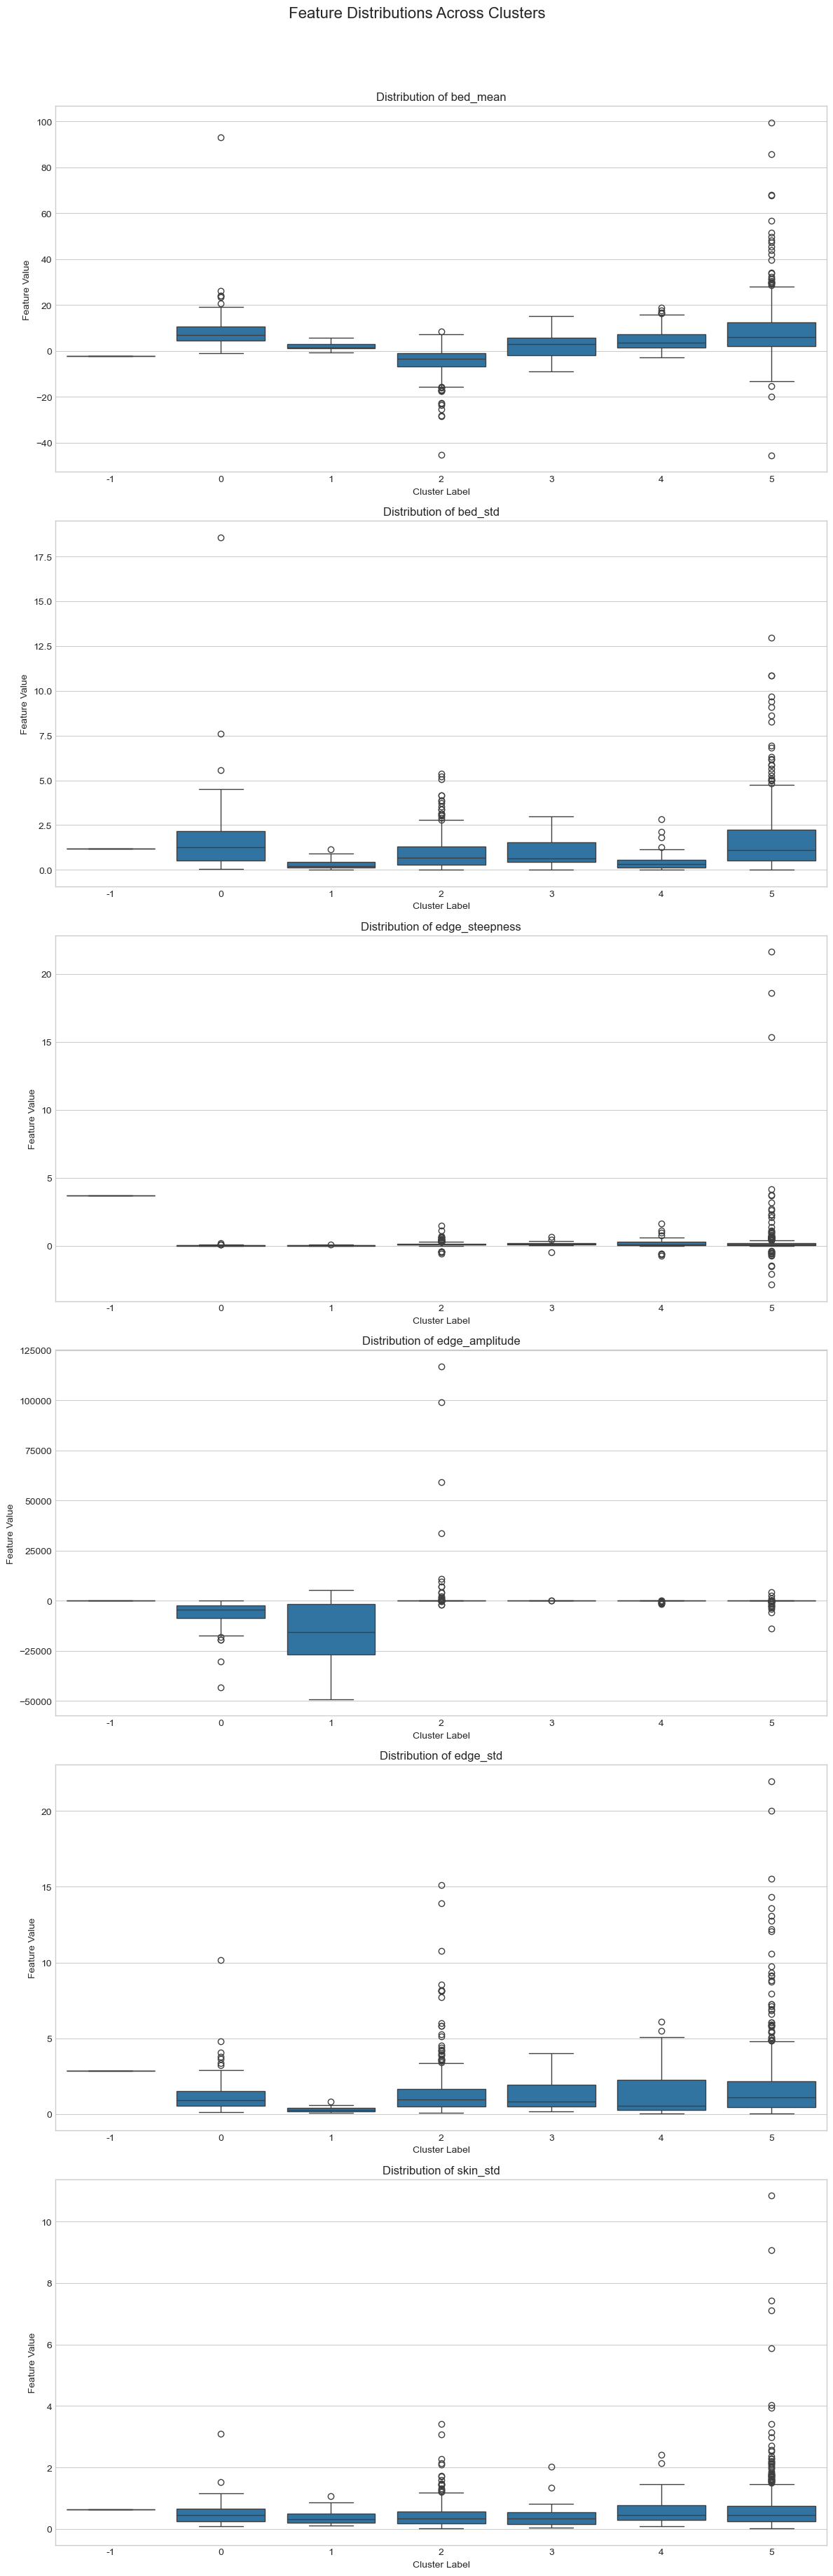

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Some features to investigate their distributions
features_to_plot = [
    'bed_mean', 'bed_std', 
    'edge_steepness', 'edge_amplitude', 'edge_std', 
    'skin_std'
]

# Create a figure to hold the subplots
fig, axes = plt.subplots(len(features_to_plot), 1, figsize=(12, 6 * len(features_to_plot)))
fig.suptitle('Feature Distributions Across Clusters', fontsize=16, y=1.02)

# Create a box plot for each feature
for i, feature in enumerate(features_to_plot):
    sns.boxplot(ax=axes[i], x='cluster_label', y=feature, data=df_clean)
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel("Cluster Label")
    axes[i].set_ylabel("Feature Value")

plt.tight_layout()
plt.show()